# caife quickstart

A minimal, self-contained walk-through of `caife` on synthetic toy data.

In [1]:
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt

import caife
from caife import examples

## Toy Data

`create_data` draws a proxy `X`, a target `y`, sample weights `w`, and a systematic parameter `S`. This data is then split into a training and a testing set.

In [2]:
(X_trn, y_trn, w_trn, S_trn), (X_tst, y_tst) = examples.split_data(
    *examples.create_data(rng=1491), rng=1491)

print(f"Shapes: X_trn {X_trn.shape}, X_tst {X_tst.shape} S_trn {S_trn.shape}")

Shapes: X_trn (100000, 1), X_tst (100000, 1) S_trn (100000, 1)


`caife` requires the `target_bins`, into which `y` will be discretized, to range from `-inf` to `inf`. The two outermost bins typically are overflow bins that catch everything outside the bins that are actually relevant to the analysis.

The `proxy_bins` should also range from `-inf` to `inf`. It is typically advisable to use more proxy bins than target bins.

In [3]:
target_bins = np.concatenate(([-np.inf], np.linspace(-4, 5, 10), [np.inf]))
proxy_bins = np.concatenate(([-np.inf], np.linspace(-6, 8, 15), [np.inf]))
print("target_bins:", target_bins)
print("proxy_bins:", proxy_bins)

target_bins: [-inf  -4.  -3.  -2.  -1.   0.   1.   2.   3.   4.   5.  inf]
proxy_bins: [-inf  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.   4.   5.   6.
   7.   8.  inf]


With the target and proxy bins defined, we can set up a simple linear count model for the data. This model does not yet consider any systematic parameters `S_trn`.

In [4]:
model = caife.LinearCountModel(target_bins, caife.UnivariateBinning(proxy_bins))
model.fit(X_trn, y_trn, sample_weight=w_trn);

Using this model, we now inspect the target distribution `f(y)` in three variants:

- the unweighted training set
- the weighted training set
- the test set

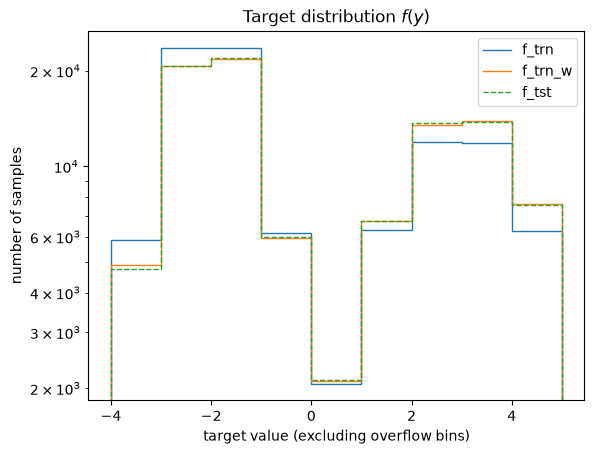

In [5]:
f_trn = model.target_view(y_trn)
f_trn_w = model.target_view(y_trn, sample_weight=w_trn)
f_tst = model.target_view(y_tst)

plt.stairs(f_trn[1:-1], edges=target_bins[1:-1], label="f_trn") # exclude over-flow bins
plt.stairs(f_trn_w[1:-1], edges=target_bins[1:-1], label="f_trn_w")
plt.stairs(f_tst [1:-1], edges=target_bins[1:-1], ls="--", label="f_tst")
plt.yscale("log")
plt.xlabel("target value (excluding overflow bins)")
plt.ylabel("number of samples")
plt.title("Target distribution $f(y)$")
plt.legend()
plt.show()

We also inspect the smeared proxy distribution `g(X)`.

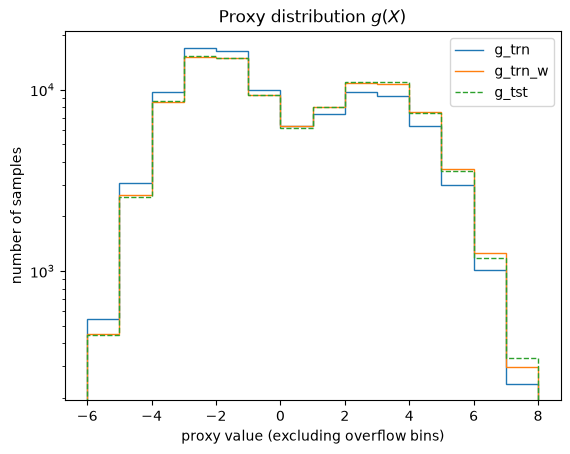

In [6]:
g_trn = model.proxy_view(X_trn)
g_trn_w = model.proxy_view(X_trn, sample_weight=w_trn)
g_tst = model.proxy_view(X_tst)

plt.stairs(g_trn[1:-1], edges=proxy_bins[1:-1], label="g_trn") # exclude over-flow bins
plt.stairs(g_trn_w[1:-1], edges=proxy_bins[1:-1], label="g_trn_w")
plt.stairs(g_tst [1:-1], edges=proxy_bins[1:-1], ls="--", label="g_tst")
plt.yscale("log")
plt.xlabel("proxy value (excluding overflow bins)")
plt.ylabel("number of samples")
plt.title("Proxy distribution $g(X)$")
plt.legend()
plt.show()